## Moving Test 1 (V2V) Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

from collections import defaultdict

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"
PLOTTING_DPI = 75
static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
STATIC_VEH, MOVING_VEH = 1, 2
VEH_NAME_MAP = {1: "static", 2: "moving"}
test_preset_map = defaultdict(dict)
test_preset_map['PLOTTING_DPI'] = PLOTTING_DPI
test_preset_map['STATIC_VEH'] = STATIC_VEH
test_preset_map['MOVING_VEH'] = MOVING_VEH
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
test_preset_map['dist_interval_size'] = 200
#############################################
# if skip plotting any tests, list them here
skiptests = []
#############################################
all_test_files, ground_truth_list = post_process_get_moving_test_data_and_timestamp(ROOT_DIR, 
                                                                                    "Moving Test 1 (V2V)", 
                                                                                    "V2", 
                                                                                    CALIBRATED_CAM_TO_V2B,
                                                                                    skiptests=skiptests)
assert(len(all_test_files) == len(ground_truth_list))
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = ground_truth_list[2*i]
moving_tests = {}

## Parse and store the data for all the tests

In [2]:
moving_tests = {}
for test in all_test_names:
    moving_tests[test] = parse_single_test_data(test_raw_name_file_map[test]["B"],
                                                "Moving Test",
                                                test_preset_map,
                                                test_raw_name_file_map[test]["ground_truth"])

processing: 2021-05-25-10-46-56-moving-v2-1-west-walking-speed
processing: 2021-05-25-10-55-51-moving-v2-1-east-reset
2021-05-25-10-55-51-moving-v2-1-east-reset No Data
processing: 2021-05-25-11-00-35-moving-v2-2-west-3mph
processing: 2021-05-25-11-02-33-moving-v2-2-east-reset
2021-05-25-11-02-33-moving-v2-2-east-reset No Data
processing: 2021-05-25-11-06-29-moving-v2-3-west-5mph
processing: 2021-05-25-11-09-46-moving-v2-3-east-reset
processing: 2021-05-25-11-13-08-moving-v2-4-west-12mph
processing: 2021-05-25-11-15-00-moving-v2-4-east-reset
processing: 2021-05-25-11-19-48-moving-v2-5-west-12mph
processing: 2021-05-25-11-21-44-moving-v2-5-east-reset
2021-05-25-11-21-44-moving-v2-5-east-reset No Data
processing: 2021-05-25-11-24-00-moving-v2-6-west-fullspeed
processing: 2021-05-25-11-26-40-moving-v2-6-east-reset


In [3]:
# Global Statistics
static_stats_list_pairwise = []
static_stats_list_aggregated = []
moving_stats_list_pairwise = []
moving_stats_list_aggregated = []

# Combination of All, Indexed by Time
list_df_time_idx_static = []
list_df_time_idx_moving = []

# Combination of All, Indexed by Ground Truth Distances
list_df_dist_idx_static = []
list_df_dist_idx_moving = []

# Combination of All, Indexed by Instance Speed by Markers
list_df_spd_idx_static = []
list_df_spd_idx_moving = []

for raw_name in all_test_names:
    parsing_results = moving_tests.get(raw_name)
    if not parsing_results:
        continue
    # Unpack dataframes
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        df_veh_spd_idx = parsing_results[veh]["df_veh_spd_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        if veh == STATIC_VEH:
            df_static_time_idx, static_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_static.append(df_veh_time_idx)
            list_df_dist_idx_static.append(df_veh_dist_idx)
            list_df_spd_idx_static.append(df_veh_spd_idx)
            static_stats_list_pairwise.append(df_stats_pairwise)
            static_stats_list_aggregated.append(df_stats_aggregated)
        elif veh == MOVING_VEH:
            df_moving_time_idx, moving_bins = df_veh_time_idx, veh_err_bins
            list_df_time_idx_moving.append(df_veh_time_idx)
            list_df_dist_idx_moving.append(df_veh_dist_idx)
            list_df_spd_idx_moving.append(df_veh_spd_idx)
            moving_stats_list_pairwise.append(df_stats_pairwise)
            moving_stats_list_aggregated.append(df_stats_aggregated)
    
df_all_static_stats_pairwise = pd.concat(static_stats_list_pairwise, ignore_index=True)
df_all_static_stats_aggregated = pd.concat(static_stats_list_aggregated, ignore_index=True)
df_all_static_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_static_stats_pairwise[(df_all_static_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_static_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])
df_all_moving_stats_pairwise = pd.concat(moving_stats_list_pairwise, ignore_index=True)
df_all_moving_stats_aggregated = pd.concat(moving_stats_list_aggregated, ignore_index=True)
df_all_moving_stats_aggregated["Main Pair Counts"] = np.array(
    df_all_moving_stats_pairwise[(df_all_moving_stats_pairwise["Is Main Master"]==True) & 
                                             (df_all_moving_stats_pairwise["Is Main Slave"]==True)
                                            ]["Reporting Counts"])

df_all_static_stats_dist_idx = pd.concat(list_df_dist_idx_static)
df_all_static_stats_time_idx = pd.concat(list_df_time_idx_static)
df_all_static_stats_spd_idx = pd.concat(list_df_spd_idx_static)
df_all_moving_stats_dist_idx = pd.concat(list_df_dist_idx_moving)
df_all_moving_stats_time_idx = pd.concat(list_df_time_idx_moving)
df_all_moving_stats_spd_idx = pd.concat(list_df_spd_idx_moving)


## Moving Test 1 Overall Stats, Downtime

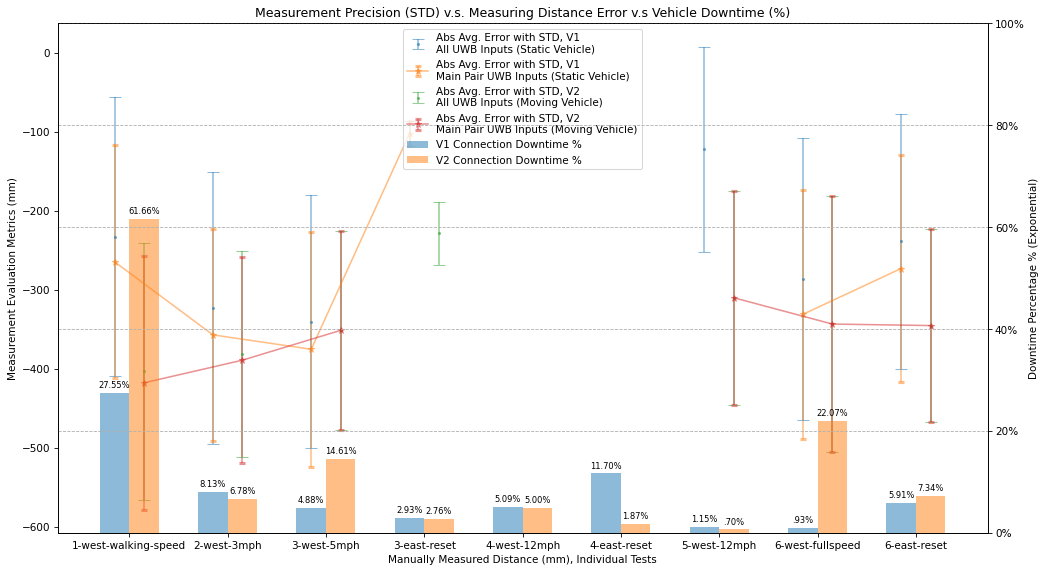

In [4]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
width=0.3
labels_static = df_all_static_stats_aggregated["Test Name"].astype(str)
labels_moving = df_all_moving_stats_aggregated["Test Name"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s Vehicle Downtime (%)")
df_main_pair_static_veh_stats_moving_test = df_all_static_stats_pairwise[
    (df_all_static_stats_pairwise["Is Main Master"]==True) & 
    (df_all_static_stats_pairwise["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_moving_test = df_all_moving_stats_pairwise[
    (df_all_moving_stats_pairwise["Is Main Master"]==True) & 
    (df_all_moving_stats_pairwise["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                       y=df_all_static_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_1_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                         y=df_main_pair_static_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_2 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                       y=df_all_moving_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
errbar_2_1 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                         y=df_main_pair_moving_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
labels = labels_static if len(labels_static) >= len(labels_moving) else labels_moving 
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(np.arange(len(labels.index)))
ax.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")

ax2 = ax.twinx()
rects1 = ax2.bar(np.arange(len(labels_static.index)) - width/2,
                 df_all_static_stats_aggregated["Downtime Duration"] / \
                 df_all_static_stats_aggregated["Operation Duration"],
                 width=width, label='V{} Connection Downtime %'.format(STATIC_VEH), alpha=0.5)
rects2 = ax2.bar(np.arange(len(labels_moving.index)) + width/2,
                 df_all_moving_stats_aggregated["Downtime Duration"] / \
                 df_all_moving_stats_aggregated["Operation Duration"],
                 width=width, label='V{} Connection Downtime %'.format(MOVING_VEH), alpha=0.5)
ax2.set_xticks(np.arange(len(labels.index)))
ax2.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax2.set_ylabel("Downtime Percentage % (Exponential)")
ax2.set_ylim([0, 1])
ax2.bar_label(rects1, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects1.datavalues], fontsize=8)
ax2.bar_label(rects2, padding=3, labels=['{:.2%}'.format(x).lstrip('0') for x in rects2.datavalues], fontsize=8)
ax2.grid(axis='y', linestyle='--')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, rects1, rects2], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(),
          rects1.get_label(), 
          rects2.get_label()],
          loc="upper center")

plt.show()

## Moving Test 1 Overall Stats, Reporting Counts

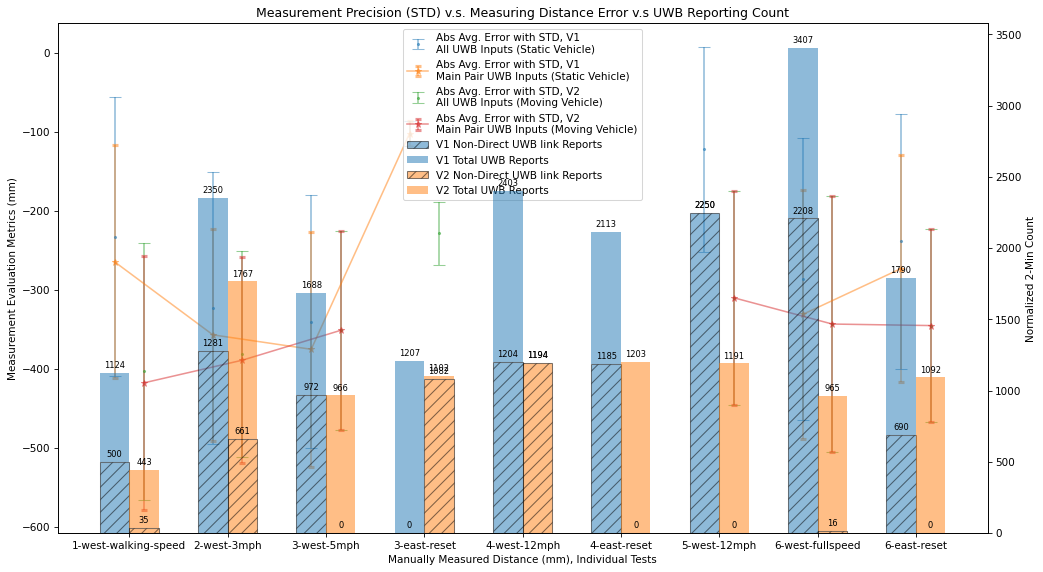

In [5]:
from matplotlib.ticker import FuncFormatter
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
width=0.3
labels_static = df_all_static_stats_aggregated["Test Name"].astype(str)
labels_moving = df_all_moving_stats_aggregated["Test Name"].astype(str)
ax = figure.add_subplot(111)
ax.set_title("Measurement Precision (STD) v.s. Measuring Distance Error v.s UWB Reporting Count")
df_main_pair_static_veh_stats_moving_test = df_all_static_stats_pairwise[
    (df_all_static_stats_pairwise["Is Main Master"]==True) & 
    (df_all_static_stats_pairwise["Is Main Slave"]==True)]
df_main_pair_moving_veh_stats_moving_test = df_all_moving_stats_pairwise[
    (df_all_moving_stats_pairwise["Is Main Master"]==True) & 
    (df_all_moving_stats_pairwise["Is Main Slave"]==True)]
errbar_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                       y=df_all_static_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_static_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_1_1 = ax.errorbar(x=np.arange(len(labels_static.index)) - width/2,
                         y=df_main_pair_static_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_static_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Static Vehicle)'.format(STATIC_VEH))
errbar_2 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                       y=df_all_moving_stats_aggregated["Average Measurement Error (mm)"],
                       yerr=df_all_moving_stats_aggregated["STD (mm)"],
                       capsize=6,
                       linestyle='None',
                       marker='o',
                       markersize=2,
                       alpha=0.5,
                       label='Abs Avg. Error with STD, V{}\nAll UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
errbar_2_1 = ax.errorbar(x=np.arange(len(labels_moving.index)) + width/2,
                         y=df_main_pair_moving_veh_stats_moving_test["Average Measurement Error (mm)"],
                         yerr=df_main_pair_moving_veh_stats_moving_test["STD (mm)"],
                         capsize=3,
                         capthick=3,
                         linestyle='-',
                         marker='*',
                         alpha=0.5,
                         label='Abs Avg. Error with STD, V{}\nMain Pair UWB Inputs (Moving Vehicle)'.format(MOVING_VEH))
labels = labels_static if len(labels_static) >= len(labels_moving) else labels_moving 
ax.set_xlabel("Manually Measured Distance (mm), Individual Tests")
ax.set_xticks(np.arange(len(labels.index)))
ax.set_xticklabels([x.split("-v2-")[1] for x in list(labels)])
ax.set_ylabel("Measurement Evaluation Metrics (mm)")

ax2 = ax.twinx()

rects1 = ax2.bar(np.arange(len(labels_static.index)) - width/2,
                (df_all_static_stats_aggregated["Main Pair Counts"] /
                 df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"), 
                 bottom=((df_all_static_stats_aggregated["Reporting Counts"] - 
                         df_all_static_stats_aggregated["Main Pair Counts"]) /
                        df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Total UWB Reports'.format(STATIC_VEH), alpha=0.5, color="C0")
rects0 = ax2.bar(np.arange(len(labels_static.index)) - width/2,
                ((df_all_static_stats_aggregated["Reporting Counts"] - 
                  df_all_static_stats_aggregated["Main Pair Counts"]) / 
                 df_all_static_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Non-Direct UWB link Reports'.format(STATIC_VEH), 
                 alpha=0.5, color="C0", hatch="//", edgecolor='k')


rects3 = ax2.bar(np.arange(len(labels_moving.index)) + width/2,
                (df_all_moving_stats_aggregated["Main Pair Counts"] / 
                 df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"), 
                 bottom=((df_all_moving_stats_aggregated["Reporting Counts"] - 
                         df_all_moving_stats_aggregated["Main Pair Counts"]) / 
                        df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Total UWB Reports'.format(MOVING_VEH), alpha=0.5, color="C1")
rects2 = ax2.bar(np.arange(len(labels_moving.index)) + width/2,
                ((df_all_moving_stats_aggregated["Reporting Counts"] - 
                  df_all_moving_stats_aggregated["Main Pair Counts"]) / 
                 df_all_moving_stats_aggregated["Operation Duration"]*120).astype("int"),
                 width=width, 
                 label='V{} Non-Direct UWB link Reports'.format(MOVING_VEH), 
                 alpha=0.5, color="C1", hatch="//", edgecolor='k')

ax2.set_ylabel("Normalized 2-Min Count")
ax2.bar_label(rects1, padding=3, fontsize=8)
ax2.bar_label(rects0, padding=3, fontsize=8)
ax2.bar_label(rects3, padding=3, fontsize=8)
ax2.bar_label(rects2, padding=3, fontsize=8)
ax.legend([errbar_1, errbar_1_1, errbar_2, errbar_2_1, 
           rects0, rects1, rects2, rects3], 
          [errbar_1.get_label(), errbar_1_1.get_label(), errbar_2.get_label(), errbar_2_1.get_label(), 
           rects0.get_label(), rects1.get_label(), rects2.get_label(), rects3.get_label()],
          loc="upper center")
plt.show()

## Moving Test 1 Overall Error Distribution

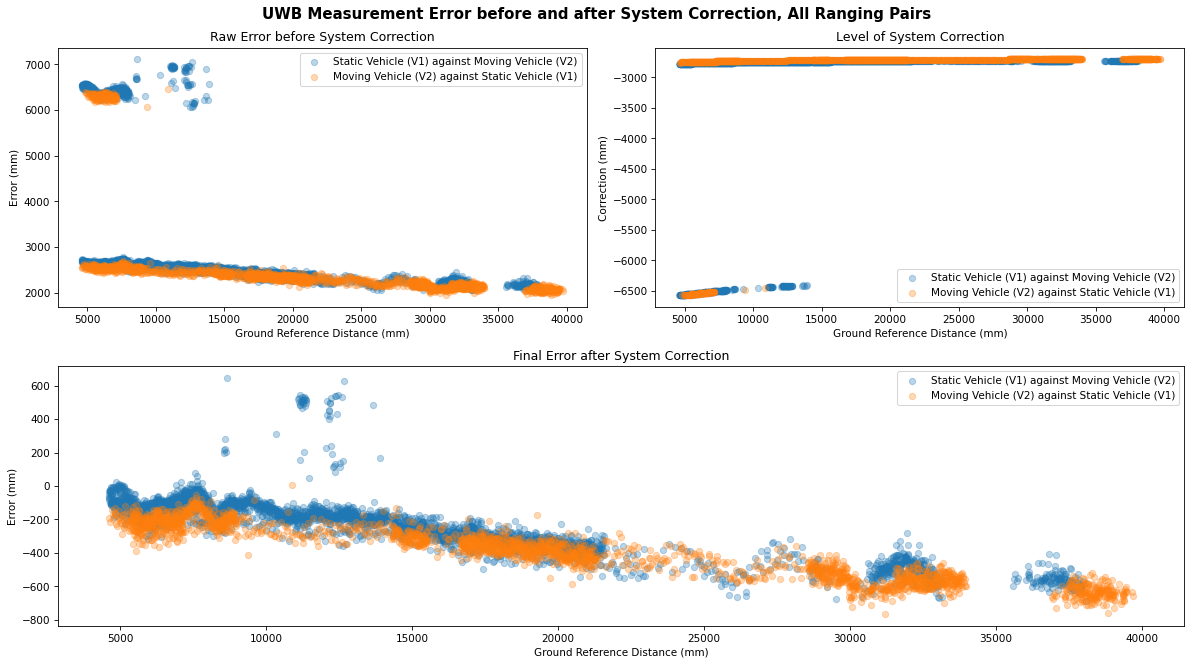

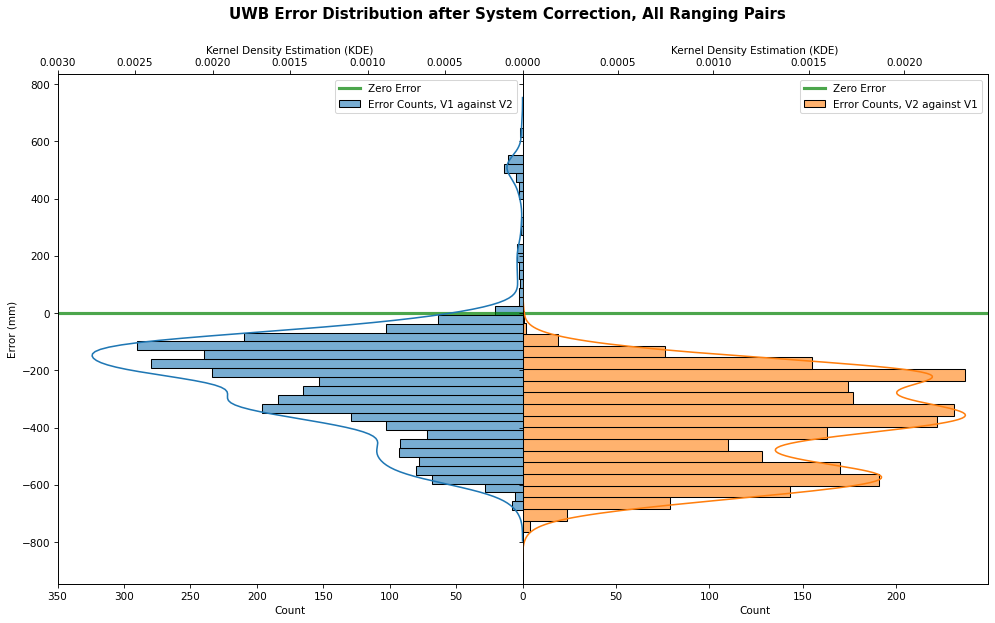

In [6]:
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax1 = figure.add_subplot(221)
ax2 = figure.add_subplot(222)
ax3 = figure.add_subplot(212)
i = 0

ax1.scatter(df_all_static_stats_dist_idx.index, 
            df_all_static_stats_dist_idx["UWB Distance (mm)"] - df_all_static_stats_dist_idx.index, 
            alpha=0.3, marker="o", color="C0",
            label="Static Vehicle (V1) against Moving Vehicle (V2)")
ax1.scatter(df_all_moving_stats_dist_idx.index, 
            df_all_moving_stats_dist_idx["UWB Distance (mm)"] - df_all_moving_stats_dist_idx.index, 
            alpha=0.3, marker="o", color="C1",
            label="Moving Vehicle (V2) against Static Vehicle (V1)")

ax2.scatter(df_all_static_stats_dist_idx.index, 
            df_all_static_stats_dist_idx['Correction Distance (mm)'] - df_all_static_stats_dist_idx['UWB Distance (mm)'],
            alpha=0.3, marker='o', color='C0',
            label="Static Vehicle (V1) against Moving Vehicle (V2)")
ax2.scatter(df_all_moving_stats_dist_idx.index, 
            df_all_moving_stats_dist_idx['Correction Distance (mm)'] - df_all_moving_stats_dist_idx['UWB Distance (mm)'],
            alpha=0.3, marker='o', color='C1',
            label="Moving Vehicle (V2) against Static Vehicle (V1)")

ax3.scatter(df_all_static_stats_dist_idx.index, 
            df_all_static_stats_dist_idx['Error (mm)'],
            alpha=0.3, marker="o", color="C0", 
            label="Static Vehicle (V1) against Moving Vehicle (V2)")
ax3.scatter(df_all_moving_stats_dist_idx.index, 
            df_all_moving_stats_dist_idx['Error (mm)'],
            alpha=0.3, marker="o", color="C1",
            label="Moving Vehicle (V2) against Static Vehicle (V1)")

ax1.set_title("Raw Error before System Correction")
ax1.set_xlabel("Ground Reference Distance (mm)")
ax1.set_ylabel("Error (mm)")
ax1.legend()

ax2.set_title("Level of System Correction")
ax2.set_xlabel("Ground Reference Distance (mm)")
ax2.set_ylabel("Correction (mm)")
ax2.legend()

ax3.set_title("Final Error after System Correction")
ax3.set_xlabel("Ground Reference Distance (mm)")
ax3.set_ylabel("Error (mm)")
ax3.legend()

figure.suptitle("UWB Measurement Error before and after System Correction, All Ranging Pairs", fontsize='x-large', fontweight='bold')
figure.tight_layout()

# Horizontal Histgram
figure2 = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
axs = figure2.subplots(1,2,sharey=True)
figure2.subplots_adjust(wspace=0)
ax_static, ax_moving = axs[0], axs[1]
ax2_static, ax2_moving = axs[0].twiny(), axs[1].twiny()

my_palette = sns.color_palette("muted")

zero_static = ax_static.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
hist_static = sns.histplot(
    data=df_all_static_stats_dist_idx.reset_index(),
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(STATIC_VEH, MOVING_VEH),
    ax=ax_static,
    color="C0"
)

kde_static = sns.kdeplot(
    data=df_all_static_stats_dist_idx.reset_index(),
    x='Error (mm)',
    ax=ax2_static,
    label="Kernel Density Distribution, V{} against V{}".format(STATIC_VEH, MOVING_VEH), 
    linewidth=1.5,
    vertical=True,
    color="C0")

zero_moving = ax_moving.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
hist_moving = sns.histplot(
    data=df_all_moving_stats_dist_idx.reset_index(),
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(MOVING_VEH, STATIC_VEH),
    ax=ax_moving,
    color="C1"
)
kde_moving = sns.kdeplot(
    data=df_all_moving_stats_dist_idx.reset_index(),
    x='Error (mm)',
    ax=ax2_moving, 
    label="Kernel Density Distribution, V{} against V{}".format(MOVING_VEH, STATIC_VEH), 
    linewidth=1.5,
    vertical=True, 
    color="C1")

ax_static.set_xlim(ax_static.get_xlim()[::-1])
ax2_static.set_xlim(ax2_static.get_xlim()[::-1])

ax2_static.set_xlabel("Kernel Density Estimation (KDE)")
ax2_moving.set_xlabel("Kernel Density Estimation (KDE)")

ax_static.set_xticks(ax_static.get_xticks()[1:])
ax2_static.set_xticks(ax2_static.get_xticks()[1:])

axs[0].legend()
axs[1].legend()

figure2.suptitle("UWB Error Distribution after System Correction, All Ranging Pairs", fontsize='x-large', fontweight='bold')

plt.show()

## Moving Test 1 Main Pair Error Distribution and Deviation Behaviors

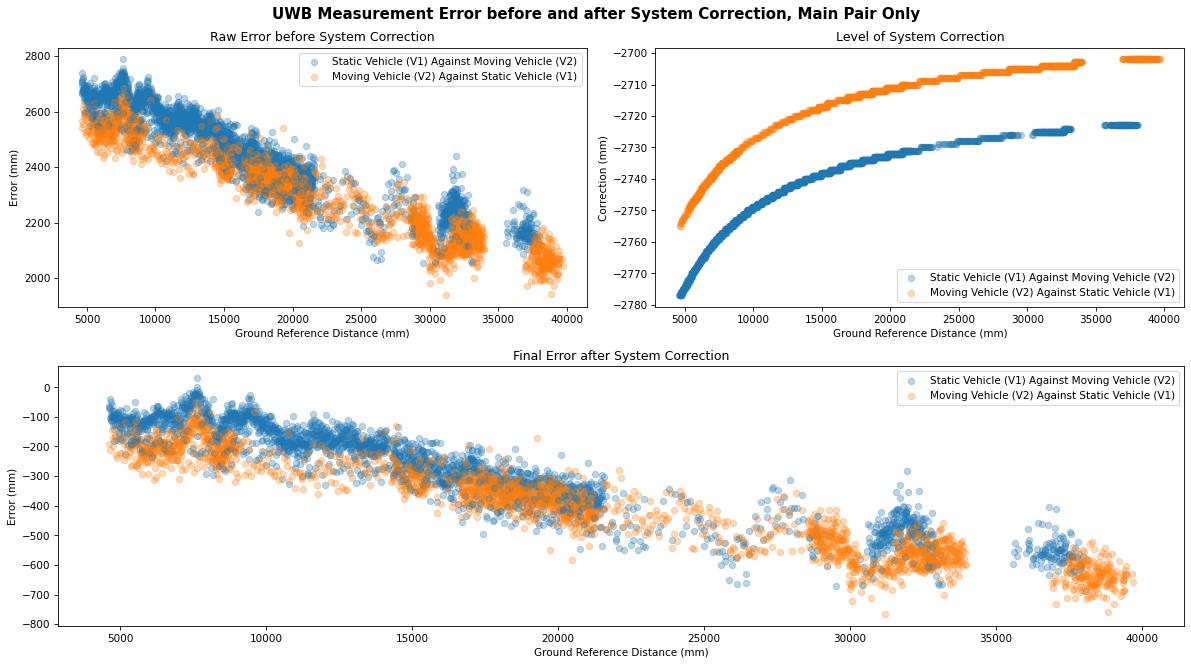

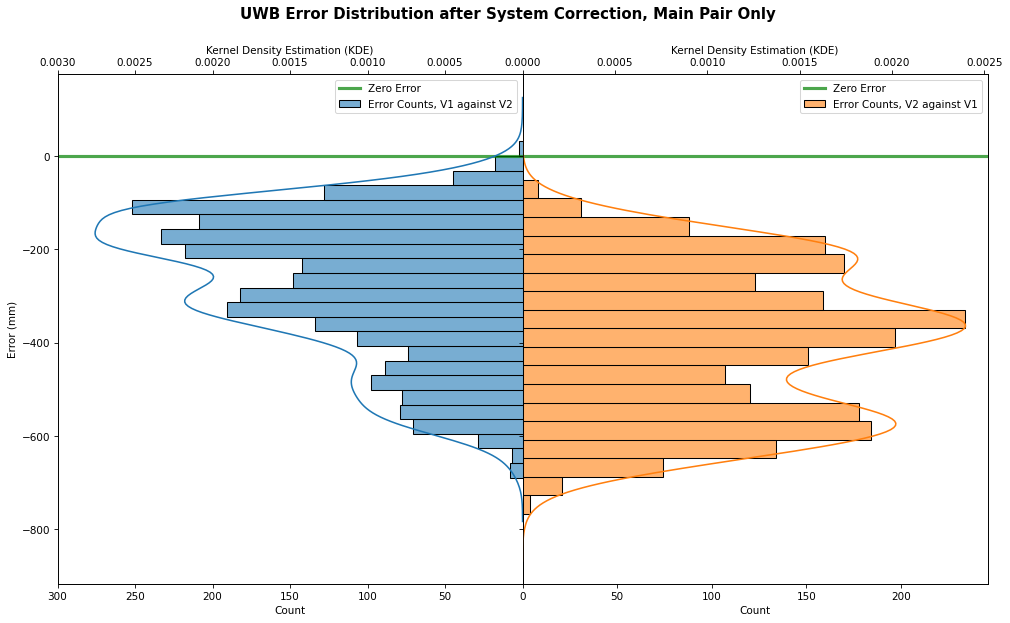

In [7]:
figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
ax1 = figure.add_subplot(221)
ax2 = figure.add_subplot(222)
ax3 = figure.add_subplot(212)

labels = df_all_static_stats_dist_idx["Test Name"].astype(str)
i = 0
for test in list(labels.unique()):
    _test_df_static = df_all_static_stats_dist_idx[(df_all_static_stats_dist_idx["Test Name"] == test) & 
        (df_all_static_stats_dist_idx['Is Main Master'] == True) & (df_all_static_stats_dist_idx['Is Main Slave'] == True)]
    _test_df_moving = df_all_moving_stats_dist_idx[(df_all_moving_stats_dist_idx["Test Name"] == test) & 
        (df_all_moving_stats_dist_idx['Is Main Master'] == True) & (df_all_moving_stats_dist_idx['Is Main Slave'] == True)]
    if i > 0:
        ax1.scatter(_test_df_static.index, 
                    _test_df_static["UWB Distance (mm)"] - _test_df_static.index, 
                    alpha=0.3, marker="o", color="C0")
        ax1.scatter(_test_df_moving.index, 
                    _test_df_moving["UWB Distance (mm)"] - _test_df_moving.index, 
                    alpha=0.3, marker="o", color="C1")

        ax2.scatter(_test_df_static.index, 
                    _test_df_static['Correction Distance (mm)'] - _test_df_static['UWB Distance (mm)'],
                    alpha=0.3, marker='o', color='C0')
        ax2.scatter(_test_df_moving.index, 
                    _test_df_moving['Correction Distance (mm)'] - _test_df_moving['UWB Distance (mm)'],
                    alpha=0.3, marker='o', color='C1')

        ax3.scatter(_test_df_static.index, 
                    _test_df_static['Error (mm)'],
                    alpha=0.3, marker="o", color="C0")
        ax3.scatter(_test_df_moving.index, 
                    _test_df_moving['Error (mm)'],
                    alpha=0.3, marker="o", color="C1")
        
    else:
        ax1.scatter(_test_df_static.index, 
                    _test_df_static["UWB Distance (mm)"] - _test_df_static.index, 
                    alpha=0.3, marker="o", color="C0",
                    label='Static Vehicle (V1) Against Moving Vehicle (V2)')
        ax1.scatter(_test_df_moving.index, 
                    _test_df_moving["UWB Distance (mm)"] - _test_df_moving.index, 
                    alpha=0.3, marker="o", color="C1",
                    label='Moving Vehicle (V2) Against Static Vehicle (V1)')

        ax2.scatter(_test_df_static.index, 
                    _test_df_static['Correction Distance (mm)'] - _test_df_static['UWB Distance (mm)'],
                    alpha=0.3, marker='o', color='C0',
                    label='Static Vehicle (V1) Against Moving Vehicle (V2)')
        ax2.scatter(_test_df_moving.index, 
                    _test_df_moving['Correction Distance (mm)'] - _test_df_moving['UWB Distance (mm)'],
                    alpha=0.3, marker='o', color='C1',
                    label='Moving Vehicle (V2) Against Static Vehicle (V1)')

        ax3.scatter(_test_df_static.index, 
                    _test_df_static['Error (mm)'],
                    alpha=0.3, marker="o", color="C0",
                    label='Static Vehicle (V1) Against Moving Vehicle (V2)')
        ax3.scatter(_test_df_moving.index, 
                    _test_df_moving['Error (mm)'],
                    alpha=0.3, marker="o", color="C1",
                    label='Moving Vehicle (V2) Against Static Vehicle (V1)')
    i += 1

ax1.set_title("Raw Error before System Correction")
ax1.set_xlabel("Ground Reference Distance (mm)")
ax1.set_ylabel("Error (mm)")
ax1.legend()

ax2.set_title("Level of System Correction")
ax2.set_xlabel("Ground Reference Distance (mm)")
ax2.set_ylabel("Correction (mm)")
ax2.legend()

ax3.set_title("Final Error after System Correction")
ax3.set_xlabel("Ground Reference Distance (mm)")
ax3.set_ylabel("Error (mm)")
ax3.legend()

figure.suptitle("UWB Measurement Error before and after System Correction, Main Pair Only", fontsize='x-large', fontweight='bold')
figure.tight_layout()

# Horizontal Histgram
figure2 = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
axs = figure2.subplots(1,2,sharey=True)
figure2.subplots_adjust(wspace=0)
ax_static, ax_moving = axs[0], axs[1]
ax2_static, ax2_moving = axs[0].twiny(), axs[1].twiny()

my_palette = sns.color_palette("muted")

zero_static = ax_static.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
static_main_pair_all = df_all_static_stats_dist_idx[(df_all_static_stats_dist_idx['Is Main Master'] == True) & 
                                                    (df_all_static_stats_dist_idx['Is Main Slave'] == True)]
moving_main_pair_all = df_all_moving_stats_dist_idx[(df_all_moving_stats_dist_idx['Is Main Master'] == True) & 
                                                    (df_all_moving_stats_dist_idx['Is Main Slave'] == True)]
hist_static = sns.histplot(
    data=static_main_pair_all.reset_index(),
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(STATIC_VEH, MOVING_VEH),
    ax=ax_static,
    color="C0"
)

kde_static = sns.kdeplot(
    data=static_main_pair_all.reset_index(),
    x='Error (mm)',
    ax=ax2_static,
    label="Kernel Density Distribution, V{} against V{}".format(STATIC_VEH, MOVING_VEH), 
    linewidth=1.5,
    vertical=True,
    color="C0")

zero_moving = ax_moving.axhline(y=0, color="g", label="Zero Error", linewidth=3, alpha=0.7)
hist_moving = sns.histplot(
    data=moving_main_pair_all.reset_index(),
    y='Error (mm)',
    alpha =0.6,
    label="Error Counts, V{} against V{}".format(MOVING_VEH, STATIC_VEH),
    ax=ax_moving,
    color="C1"
)
kde_moving = sns.kdeplot(
    data=moving_main_pair_all.reset_index(),
    x='Error (mm)',
    ax=ax2_moving, 
    label="Kernel Density Distribution, V{} against V{}".format(MOVING_VEH, STATIC_VEH), 
    linewidth=1.5,
    vertical=True, 
    color="C1")

ax_static.set_xlim(ax_static.get_xlim()[::-1])
ax2_static.set_xlim(ax2_static.get_xlim()[::-1])

ax2_static.set_xlabel("Kernel Density Estimation (KDE)")
ax2_moving.set_xlabel("Kernel Density Estimation (KDE)")

ax_static.set_xticks(ax_static.get_xticks()[1:])
ax2_static.set_xticks(ax2_static.get_xticks()[1:])

axs[0].legend()
axs[1].legend()

figure2.suptitle("UWB Error Distribution after System Correction, Main Pair Only", fontsize='x-large', fontweight='bold')

plt.show()

## Moving Test 1 Update Rate v.s. Locations, Scatter

### Static Vehicle and Moving Vehicle

C:\Users\wangz\.conda\envs\py37iot\lib\site-packages\ipykernel_launcher.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator


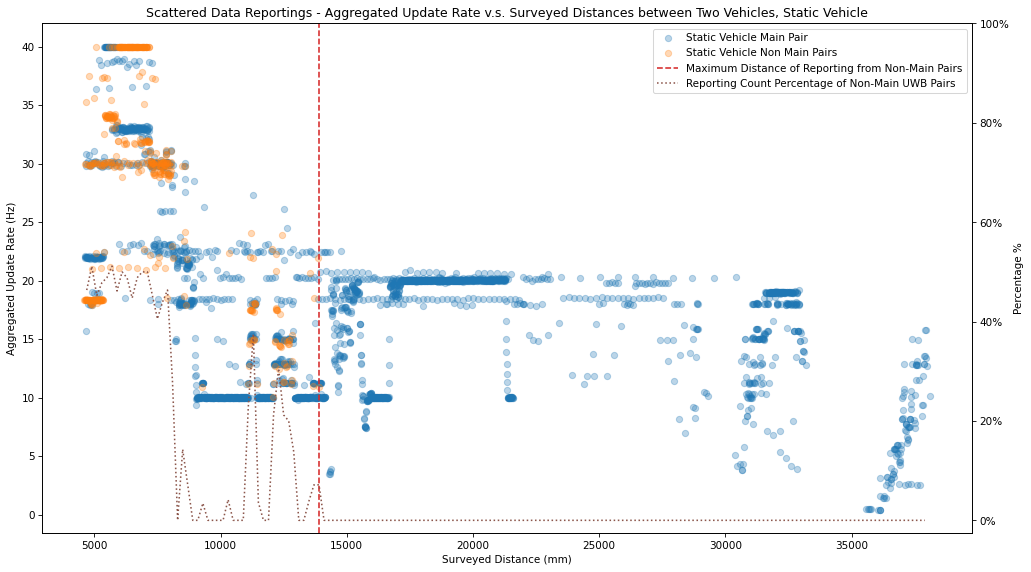

C:\Users\wangz\.conda\envs\py37iot\lib\site-packages\ipykernel_launcher.py:68: UserWarning: FixedFormatter should only be used together with FixedLocator


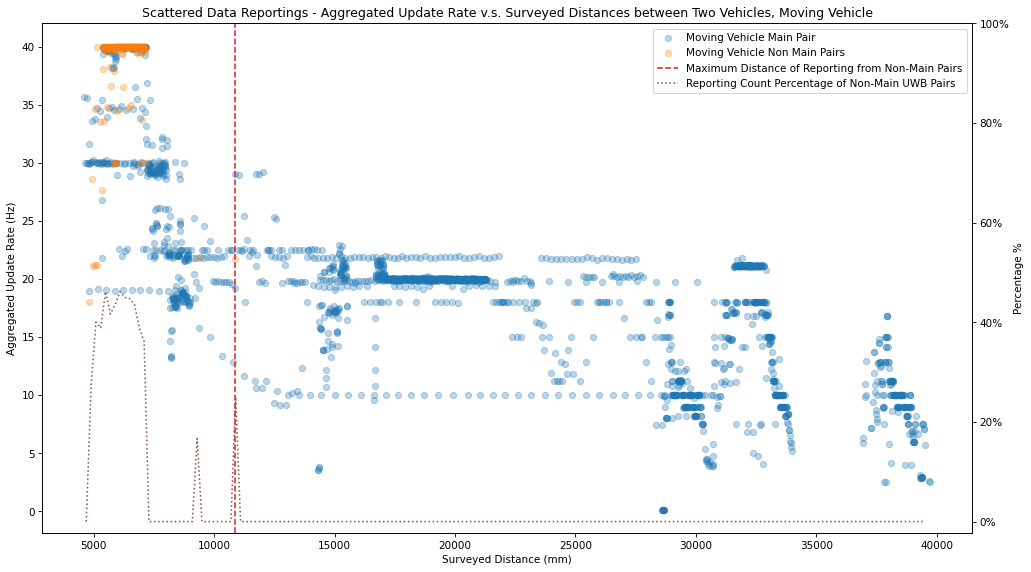

In [8]:
binsize = 200

for df_veh_dist_idx_all_tests in [df_all_static_stats_dist_idx, df_all_moving_stats_dist_idx]:
    if df_veh_dist_idx_all_tests['Initiating Vehicle'].unique()[0] == STATIC_VEH:
        veh_name = "Static"
    if df_veh_dist_idx_all_tests['Initiating Vehicle'].unique()[0] == MOVING_VEH:
        veh_name = "Moving"
    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    ax = figure.add_subplot(111)
    main_df = df_veh_dist_idx_all_tests[
        (df_veh_dist_idx_all_tests["Is Main Master"] == True) & 
        (df_veh_dist_idx_all_tests["Is Main Slave"] == True)
    ]
    main_df = main_df[main_df.index.notnull()]

    non_main_df = df_veh_dist_idx_all_tests[
        (df_veh_dist_idx_all_tests["Is Main Master"] != True) | 
        (df_veh_dist_idx_all_tests["Is Main Slave"] != True)
    ]
    non_main_df = non_main_df[non_main_df.index.notnull()]

    # Aggregated
    main_scatter = ax.scatter(main_df.index, 
                            main_df["Aggregated Update Rate (Hz)"], 
                            label="{} Vehicle Main Pair".format(veh_name),
                            color="C0",
                            alpha=0.3)
            
    # Aggregated
    non_main_scatter = ax.scatter(non_main_df.index, 
                                non_main_df["Aggregated Update Rate (Hz)"], 
                                label="{} Vehicle Non Main Pairs".format(veh_name),
                                color="C1",
                                alpha=0.3)
    v_line = ax.axvline(non_main_df.index.max(), 
                        linestyle="--", 
                        color="C3",
                        label="Maximum Distance of Reporting from Non-Main Pairs")
    ax.set_xlabel("Surveyed Distance (mm)")
    ax.set_ylabel("Aggregated Update Rate (Hz)")
    ax.set_title("Scattered Data Reportings - Aggregated Update Rate v.s. Surveyed Distances between Two Vehicles, {} Vehicle".format(veh_name))

    ax2 = ax.twinx()
    bins = np.arange(0, max(main_df.index.max(), non_main_df.index.max()), binsize)
    _percent_df_main = pd.DataFrame(
        data=main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(main_df.index, bins)).size(),
        columns=["count"])
    _percent_df_non_main = pd.DataFrame(
        data=non_main_df[["Instant Update Rate (Hz)", "Aggregated Update Rate (Hz)"]].groupby(pd.cut(non_main_df.index, bins)).size(),
        columns=["count"])
    _percent_df = pd.DataFrame()
    _percent_df["total"] = _percent_df_main["count"] + _percent_df_non_main["count"]
    _percent_df["main count"] = _percent_df_main["count"]
    _percent_df["non main count"] = _percent_df_non_main["count"]
    _percent_df["percent non main"] = _percent_df["non main count"] / _percent_df["total"]
    _percent_df['mid'] = [i.mid for i in _percent_df.index.array]

    percent_line = ax2.plot(_percent_df[_percent_df["percent non main"] >= 0]["mid"], 
                            _percent_df[_percent_df["percent non main"] >= 0]["percent non main"],
                            label="Reporting Count Percentage of Non-Main UWB Pairs",
                            linestyle=":",
                            color="C5")
    ax2.set_ylabel("Percentage %")
    l = ax.legend([main_scatter, non_main_scatter, v_line, percent_line[0]], 
                [main_scatter.get_label(), non_main_scatter.get_label(), v_line.get_label(), percent_line[0].get_label()])
    ax2.set_ylim(top=1)
    _yticks = ax2.get_yticks()
    ax2.set_yticklabels(['{:,.0%}'.format(x) for x in _yticks])
    plt.show()

## Moving Test 1 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances

### Both Vehicles, Excluding Loss of Connection

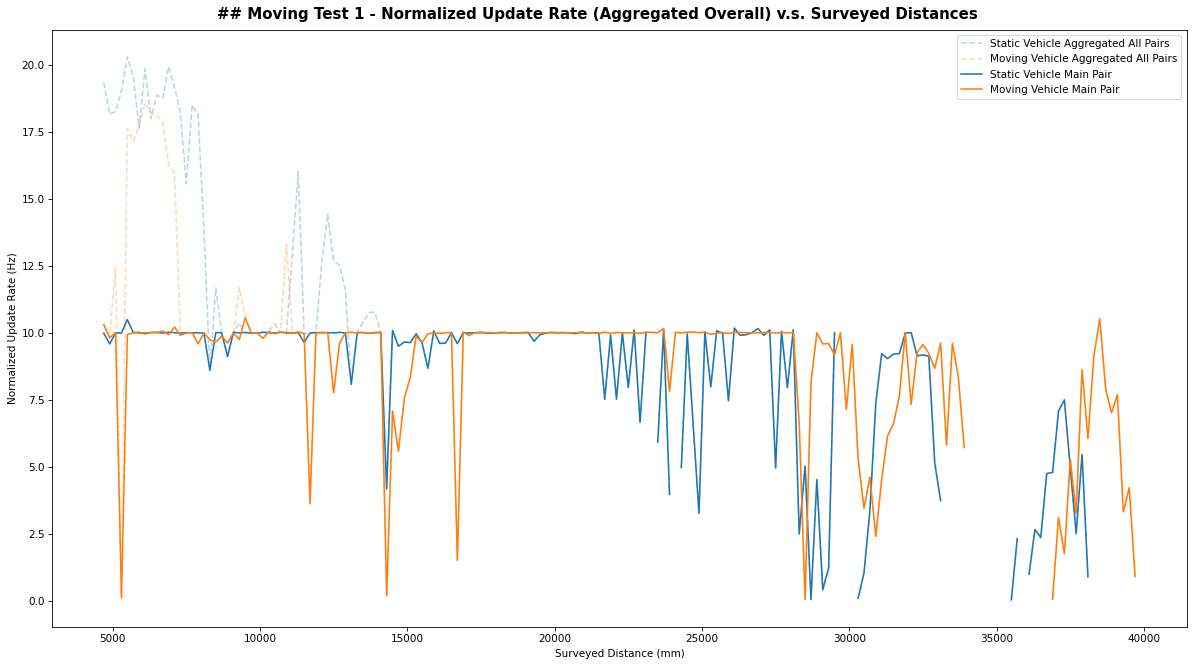

In [9]:
titlename = "## Moving Test 1 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances"
dist_binsize = 200 if not test_preset_map.get('dist_interval_size') else test_preset_map.get('dist_interval_size')
interval_idx_stats_map = defaultdict(dict)
for veh_dist_idx_df_list in [list_df_dist_idx_static, list_df_dist_idx_moving]:
    veh = veh_dist_idx_df_list[0]['Initiating Vehicle'].unique()[0]
    interval_idx_stats_map[veh]['aggregated'] = dist_interval_idx_df_by_veh_all_tests(  veh_dist_idx_df_list, 
                                                                                        dist_binsize, 
                                                                                        test_preset_map)
    interval_idx_stats_map[veh]['main'] = dist_interval_idx_df_by_veh_all_tests(veh_dist_idx_df_list, 
                                                                                dist_binsize,
                                                                                test_preset_map,
                                                                                main_pair=True)
figure = plt.figure(figsize=(16, 9), dpi=test_preset_map['PLOTTING_DPI'])
figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
plot_dist_idx_udpate_rate(      figure,
                                interval_idx_stats_map,
                                STATIC_VEH,
                                MOVING_VEH,
                                test_preset_map,
                                dist_bin=dist_binsize)
plt.show()

### Both Vehicles, Including Loss of Connection

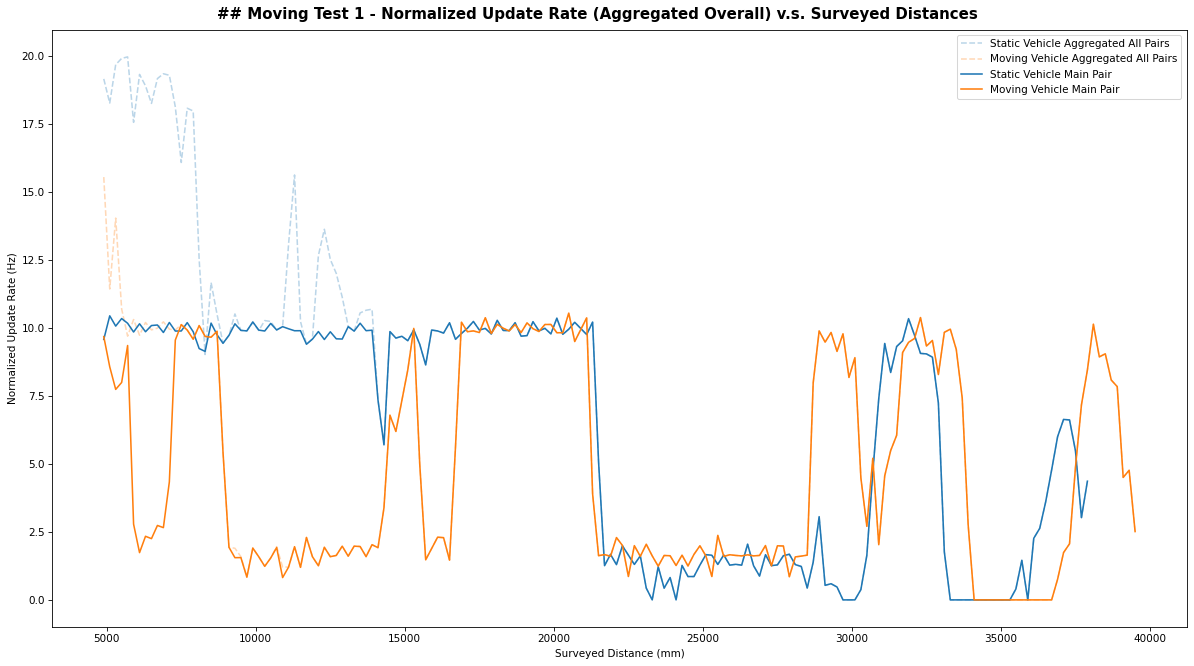

In [10]:
titlename = "## Moving Test 1 - Normalized Update Rate (Aggregated Overall) v.s. Surveyed Distances"
dist_binsize = 200 if not test_preset_map.get('dist_interval_size') else test_preset_map.get('dist_interval_size')
interval_idx_stats_map = defaultdict(dict)
for veh_dist_idx_df_list in [list_df_dist_idx_static, list_df_dist_idx_moving]:
    veh = veh_dist_idx_df_list[0]['Initiating Vehicle'].unique()[0]
    interval_idx_stats_map[veh]['aggregated'] = dist_interval_idx_df_by_veh_all_tests_monotonic(veh_dist_idx_df_list, dist_binsize)
    interval_idx_stats_map[veh]['main'] = dist_interval_idx_df_by_veh_all_tests_monotonic(  veh_dist_idx_df_list, 
                                                                                dist_binsize,
                                                                                test_preset_map[veh]['main_master'], 
                                                                                test_preset_map[veh]['master_slave_mapping'][test_preset_map[veh]['main_master']][0])
figure = plt.figure(figsize=(16, 9), dpi=test_preset_map['PLOTTING_DPI'])
figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
plot_dist_idx_udpate_rate(      figure,
                                interval_idx_stats_map,
                                STATIC_VEH,
                                MOVING_VEH,
                                test_preset_map,
                                dist_bin=dist_binsize)
plt.show()

## Moving Test 1 - Reporting Count Bar Chart v.s. Surveyed Distances

### Static Vehicle & Moving Vehicle

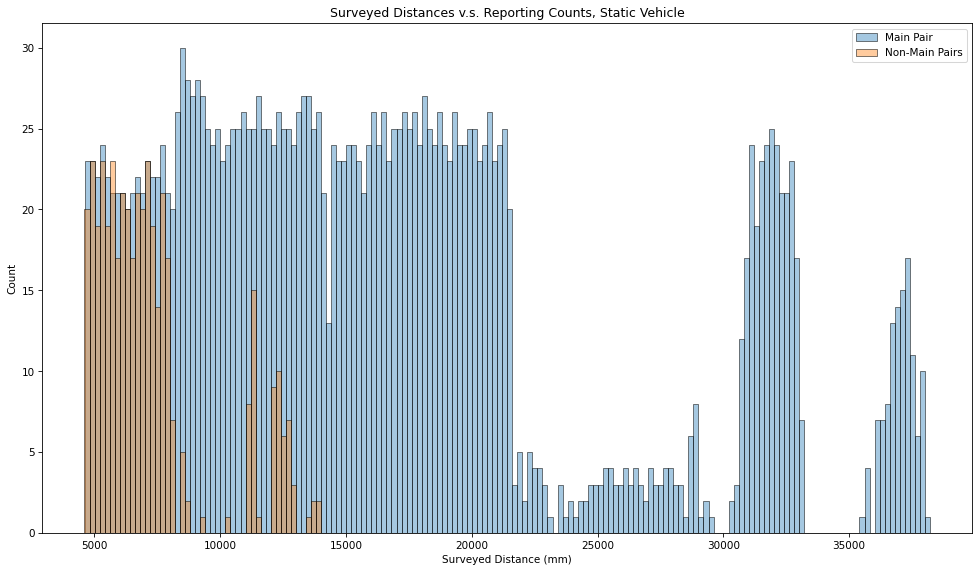

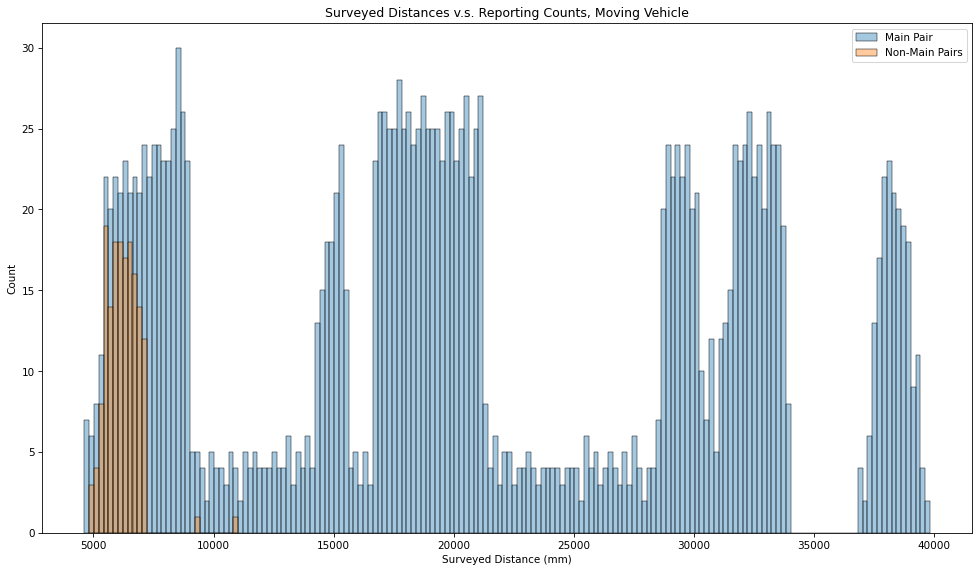

In [11]:
dist_bin = 200

for df_veh_time_idx_all_tests in [df_all_static_stats_time_idx, df_all_moving_stats_time_idx]:
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == STATIC_VEH:
        veh_name = "Static"
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == MOVING_VEH:
        veh_name = "Moving"
    main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] == True) & 
        (df_veh_time_idx_all_tests["Is Main Slave"] == True)
    ]
    main_df = main_df[main_df.index.notnull()]

    non_main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] != True) | 
        (df_veh_time_idx_all_tests["Is Main Slave"] != True)
    ]
    non_main_df = non_main_df[non_main_df.index.notnull()]

    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    ax1 = figure.add_subplot(111)

    # Main Pair
    hist_1 = sns.histplot(data=main_df.reset_index(), 
                        x=main_df.reset_index()["Surveyed Distance (mm)"],
                        binwidth=dist_bin, 
                        ax=ax1, 
                        color="C0", 
                        alpha=0.4, 
                        label="Main Pair")

    # Non-Main Pairs
    hist_2 = sns.histplot(data=non_main_df.reset_index(), 
                        x=non_main_df.reset_index()["Surveyed Distance (mm)"],
                        binwidth=dist_bin, 
                        ax=ax1, 
                        color="C1", 
                        alpha=0.4, 
                        label="Non-Main Pairs")
    ax1.set_title("Surveyed Distances v.s. Reporting Counts, {} Vehicle".format(veh_name))
    ax1.legend()
plt.show()

## Heat Map of Data Reporting Points when Instant Update Rate Cannot Reach 10Hz

### Static Vehicle & Moving Vehicle

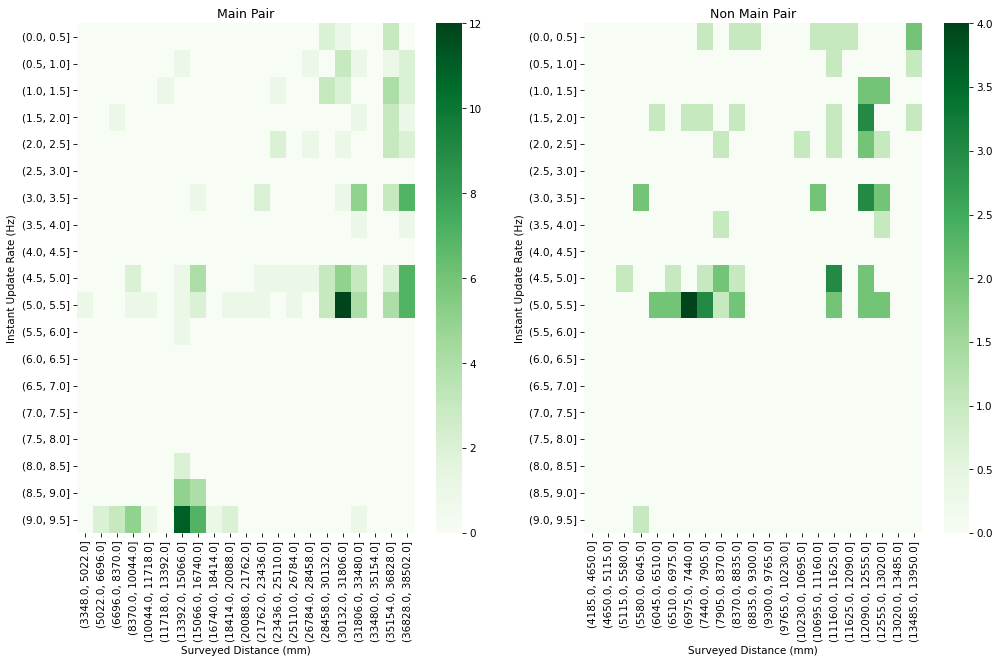

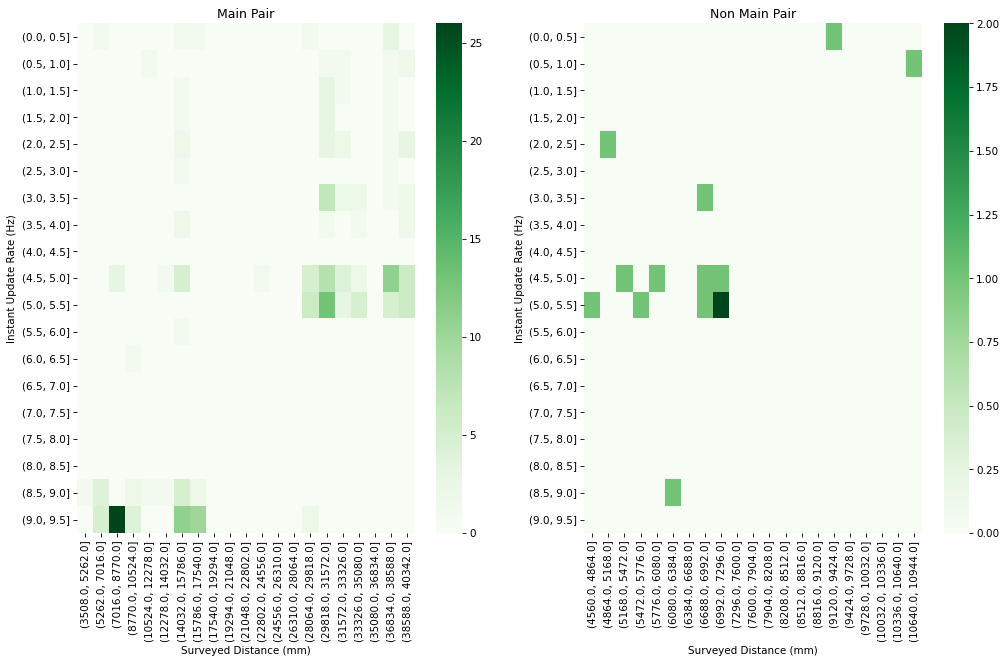

In [12]:
for df_veh_time_idx_all_tests in [df_all_static_stats_time_idx, df_all_moving_stats_time_idx]:
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == STATIC_VEH:
        veh_name = "Static"
    if df_veh_time_idx_all_tests['Initiating Vehicle'].unique()[0] == MOVING_VEH:
        veh_name = "Moving"
    main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] == True) & 
        (df_veh_time_idx_all_tests["Is Main Slave"] == True)
    ]
    main_df = main_df[main_df.index.notnull()]

    non_main_df = df_veh_time_idx_all_tests[
        (df_veh_time_idx_all_tests["Is Main Master"] != True) | 
        (df_veh_time_idx_all_tests["Is Main Slave"] != True)
    ]
    non_main_df = non_main_df[non_main_df.index.notnull()]

    _veh_dist_notnull_main = main_df["Surveyed Distance (mm)"].dropna()
    _veh_hz_notnull_main = main_df["Instant Update Rate (Hz)"].dropna()
    _veh_dist_notnull_non_main = non_main_df["Surveyed Distance (mm)"].dropna()
    _veh_hz_notnull_non_main = non_main_df["Instant Update Rate (Hz)"].dropna()
    min_update_rate_regarded_as_normal = 9.9
    bin_count = 20

    dist_bin_main = round((max(_veh_dist_notnull_main) - min(_veh_dist_notnull_main)) / bin_count, 0)
    hz_bin_main = round((min_update_rate_regarded_as_normal - min(_veh_hz_notnull_main)) / bin_count, 1)

    dist_bin_non_main = round((max(_veh_dist_notnull_non_main) - min(_veh_dist_notnull_non_main)) / bin_count, 0)
    hz_bin_non_main = max(round((min_update_rate_regarded_as_normal - min(_veh_hz_notnull_non_main)) / bin_count, 1), 0.1)

    dist_bins_main = np.arange(dist_bin_main * (min(_veh_dist_notnull_main) // dist_bin_main), 
                            dist_bin_main * ((max(_veh_dist_notnull_main) + dist_bin_main) // dist_bin_main + 1), 
                            dist_bin_main)
    hz_bins_main = np.arange(hz_bin_main * (min(_veh_hz_notnull_main) // hz_bin_main), 
                            hz_bin_main * ((max(_veh_hz_notnull_main) + hz_bin_main) // hz_bin_main + 1), 
                            hz_bin_main)

    dist_bins_non_main = np.arange(dist_bin_non_main * (min(_veh_dist_notnull_non_main) // dist_bin_non_main), 
                                dist_bin_non_main * ((max(_veh_dist_notnull_non_main) + dist_bin_non_main) // dist_bin_non_main + 1), 
                                dist_bin_non_main)
    hz_bins_non_main = np.arange(hz_bin_non_main * (min(_veh_hz_notnull_non_main) // hz_bin_non_main), 
                                hz_bin_non_main * ((max(_veh_hz_notnull_non_main) + hz_bin_non_main) // hz_bin_non_main + 1), 
                                hz_bin_non_main)

    df_main_pair_assorted = pd.DataFrame(index=(main_df["Instant Update Rate (Hz)"]
                                                .dropna()
                                                .groupby(pd.cut(main_df["Instant Update Rate (Hz)"].dropna(), 
                                                                hz_bins_main))
                                                .count()
                                                .index),
                                        columns=(main_df["Surveyed Distance (mm)"]
                                                .dropna()
                                                .groupby(pd.cut(main_df["Surveyed Distance (mm)"].dropna(), 
                                                                dist_bins_main))
                                                .count()
                                                .index)
                                        ).replace(np.nan, 0)

    df_non_main_assorted = pd.DataFrame(index=(non_main_df["Instant Update Rate (Hz)"]
                                            .dropna()
                                            .groupby(pd.cut(non_main_df["Instant Update Rate (Hz)"].dropna(), 
                                                            hz_bins_non_main))
                                            .count()
                                            .index),
                                        columns=(non_main_df["Surveyed Distance (mm)"]
                                                .dropna()
                                                .groupby(pd.cut(non_main_df["Surveyed Distance (mm)"].dropna(), 
                                                                dist_bins_non_main))
                                                .count()
                                                .index)
                                        ).replace(np.nan, 0)

    for index, row in main_df.iterrows():
        if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
            continue
        df_main_pair_assorted.iloc[
            df_main_pair_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
            df_main_pair_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
        ] += 1
    for index, row in non_main_df.iterrows():
        if pd.isnull(row["Instant Update Rate (Hz)"]) or pd.isnull(row["Surveyed Distance (mm)"]):
            continue
        df_non_main_assorted.iloc[
            df_non_main_assorted.index.get_loc(row["Instant Update Rate (Hz)"]),
            df_non_main_assorted.columns.get_loc(row["Surveyed Distance (mm)"])
        ] += 1
    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    if not df_non_main_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]].empty:
        ax1 = figure.add_subplot(121)
        h1 = sns.heatmap(df_main_pair_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                    cmap="Greens")

        ax1.set_title("Main Pair")
        ax2 = figure.add_subplot(122)
        h2 = sns.heatmap(df_non_main_assorted.loc[
            [i.right < min_update_rate_regarded_as_normal for i in df_non_main_assorted.index.array]],
                        cmap="Greens")
        ax2.set_title("Non Main Pair")
    else:
        ax1 = figure.add_subplot(111)
        h1 = sns.heatmap(df_main_pair_assorted.loc[
        [i.right < min_update_rate_regarded_as_normal for i in df_main_pair_assorted.index.array]],
                    cmap="Greens")
        ax1.set_title("Main Pair (Non Main Pair Empty)")
plt.show()

## Normalized Update Rate v.s. Relative/Absolute Relative Speed, Aggregated/Main Pairs

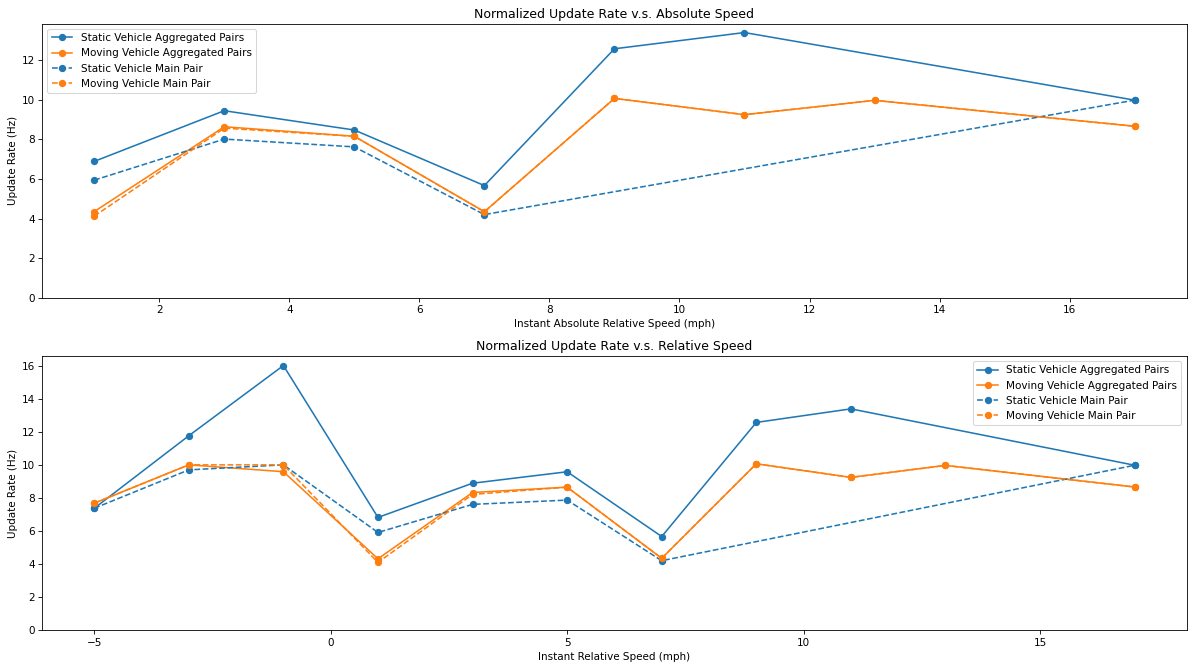

In [13]:
spd_binsize = 2 if not test_preset_map.get('spd_interval_size') else test_preset_map.get('spd_interval_size')
spd_range=[-30, 30]
figure = plt.figure(figsize=(16, 9), dpi=test_preset_map['PLOTTING_DPI'])
spd_interval_idx_stats_map = defaultdict(dict)
for veh_spd_idx_df_list in [list_df_spd_idx_static, list_df_spd_idx_moving]:
    veh = veh_spd_idx_df_list[0]['Initiating Vehicle'].unique()[0]
    spd_interval_idx_stats_map[veh]['aggregated'] = {}
    spd_interval_idx_stats_map[veh]['aggregated']['non-abs'] = spd_interval_idx_df_by_veh_all_tests(veh_spd_idx_df_list, 
                                                                                                spd_binsize, 
                                                                                                spd_range, 
                                                                                                test_preset_map, 
                                                                                                min_reporting_cnts=10)
    spd_interval_idx_stats_map[veh]['aggregated']['abs'] = spd_interval_idx_df_by_veh_all_tests(veh_spd_idx_df_list, 
                                                                                            spd_binsize, 
                                                                                            spd_range, 
                                                                                            test_preset_map, 
                                                                                            absolute=True,
                                                                                            min_reporting_cnts=10)
    spd_interval_idx_stats_map[veh]['main'] = {}
    spd_interval_idx_stats_map[veh]['main']['non-abs'] = spd_interval_idx_df_by_veh_all_tests(   veh_spd_idx_df_list, 
                                                                                    spd_binsize,
                                                                                    spd_range,
                                                                                    test_preset_map, 
                                                                                    main_pair=True,
                                                                                    min_reporting_cnts=10)
    spd_interval_idx_stats_map[veh]['main']['abs'] = spd_interval_idx_df_by_veh_all_tests(   veh_spd_idx_df_list, 
                                                                                    spd_binsize,
                                                                                    spd_range,
                                                                                    test_preset_map, 
                                                                                    main_pair=True,
                                                                                    absolute=True,
                                                                                    min_reporting_cnts=10)
plot_spd_idx_udpate_rate(   figure,
                            spd_interval_idx_stats_map,
                            STATIC_VEH,
                            MOVING_VEH)
plt.show()